### Подготовка данных

In [1]:
import warnings
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-writing-paper-sales.csv"
time_series = pd.read_csv(url)

time_series.sample(5)

,Month,Sales
97,9-02,1990.905
11,1-12,1314.325
107,9-12,1972.145
103,9-08,511.210
140,12-09,2220.715


In [2]:
len(time_series)

147

In [3]:
time_series.isnull().sum()

,0
Month,0
Sales,0


In [4]:
time_series.dtypes

,0
Month,object
Sales,float64


In [5]:
#time_series['Month'] = pd.to_datetime(time_series['Month'])
time_series['Month'] = time_series['Month'].apply(
    lambda s: pd.Timestamp(year=1900 + int(s.split('-')[0]),
                           month=int(s.split('-')[1]),
                           day=1)
)
time_series.set_index('Month', inplace=True)

In [6]:
time_series.dtypes

,0
Sales,float64


In [7]:
time_series.sample(5)

,Sales
Month,
1905-03-01,1922.900
1910-06-01,2483.355
1913-01-01,1488.371
1909-05-01,1876.000
1907-10-01,2061.255


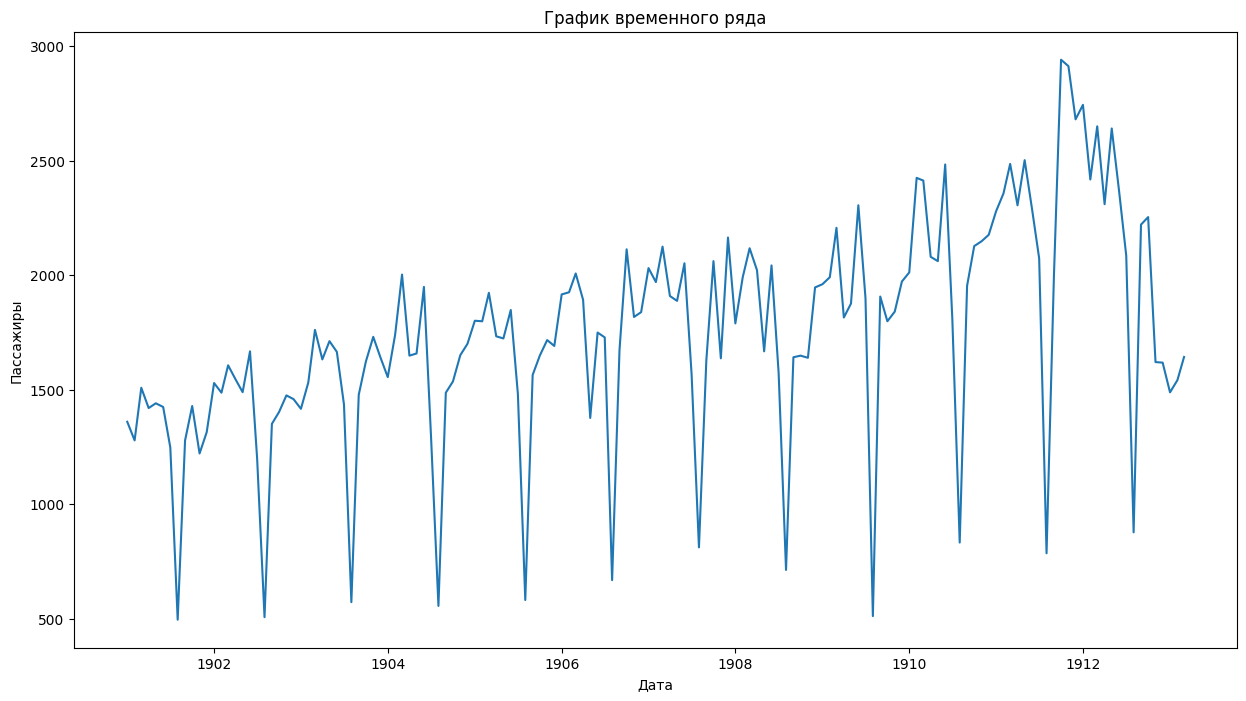

In [8]:
plt.figure(figsize=(15,8))
plt.plot(time_series['Sales'])
plt.title('График временного ряда')
plt.xlabel('Дата')
plt.ylabel('Пассажиры')
plt.show()

In [9]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings("ignore")

In [10]:
train, test = train_test_split(time_series, test_size=0.2, shuffle=False)

In [11]:
train.shape

(117, 1)

In [12]:
test.shape

(30, 1)

In [13]:
test.head()

,Sales
Month,
1910-10-01,2126.915
1910-11-01,2148.020
1910-12-01,2176.160
1911-01-01,2279.340
1911-02-01,2356.725


### Обучение модели

In [14]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

class MLARWrapper:
    """
    Обучает ML‑модель на лагах и эмулирует интерфейс statsmodels ARIMA:
    - resid   (остатки на обучающей выборке)
    - forecast(steps)
    - simulate(nsimulations, anchor='end', repetitions=1, random_errors=None)
    """
    def __init__(self, model, lags=12):
        """
        model : объект sklearn‑регрессора (например, RandomForestRegressor)
        lags  : количество запаздывающих наблюдений (p)
        """
        self.model = model
        self.lags = lags

    def fit(self, train_series):
        """
        train_series : pd.Series или np.array – одномерный временной ряд
        """
        y = train_series.values.reshape(-1, 1) if isinstance(train_series, pd.Series) else train_series
        X, y_target = self._build_lags(y, self.lags)
        self.model.fit(X, y_target)

        # Сохраняем ряд для дальнейшего прогнозирования
        self._fitted_series = y.ravel()
        # Вычисляем остатки на обучении
        y_pred = self.model.predict(X)
        self.resid = y_target - y_pred          # атрибут, как у ARIMA
        self._last_vals = y[-self.lags:].ravel() # последние известные значения
        return self

    def _build_lags(self, y, p):
        """Строит матрицу лагов и целевой вектор."""
        n = len(y)
        X = np.zeros((n-p, p))
        for i in range(p, n):
            X[i-p] = y[i-p:i].ravel()
        y_target = y[p:].ravel()
        return X, y_target

    def predict(self, X):
        """Предсказание по матрице признаков (лагов)."""
        return self.model.predict(X)

    def forecast(self, steps):
        """Рекурсивный точечный прогноз на 'steps' шагов."""
        forecast_vals = np.zeros(steps)
        last_vals = self._last_vals.copy()  # стартовый вектор лагов
        for i in range(steps):
            pred = self.model.predict(last_vals.reshape(1, -1))[0]
            forecast_vals[i] = pred
            # сдвигаем лаги: добавляем новый прогноз
            last_vals = np.append(last_vals[1:], pred)
        return forecast_vals

    def simulate(self, nsimulations, anchor='end', repetitions=1, random_errors=None):
        """
        Симуляция будущих значений с возможность передачи пользовательских ошибок.
        random_errors : np.array формы (steps,) или (steps,1) – шум, добавляемый после predict.
        """
        # В данный момент repetitions не используется, можно игнорировать
        steps = nsimulations
        sim_vals = np.zeros(steps)
        last_vals = self._last_vals.copy()
        errors = random_errors.ravel() if random_errors is not None else np.zeros(steps)
        for i in range(steps):
            pred = self.model.predict(last_vals.reshape(1, -1))[0]
            sim_vals[i] = pred + errors[i]
            # обновляем лаги
            last_vals = np.append(last_vals[1:], sim_vals[i])
        return sim_vals

In [15]:
from sklearn.ensemble import RandomForestRegressor

ml_model = MLARWrapper(model=RandomForestRegressor(n_estimators=100, random_state=42),
                       lags=12)

fitted_model = ml_model.fit(train['Sales'])

### Реализации бутстрапа

In [16]:
def residual_bootstrap(fitted_model, steps, n_bootstrap=1000):
    residuals = fitted_model.resid
    forecasts = []

    for _ in range(n_bootstrap):
        boot_resid = np.random.choice(residuals, size=steps, replace=True)
        # Симуляция будущих значений с учётом структуры модели
        sim = fitted_model.simulate(
            nsimulations=steps,
            anchor='end',          # начать с конца обучающей выборки
            repetitions=1,
            random_errors=boot_resid.reshape(-1,1)  # передаём бутстреп-остатки
        )

        sim_values = np.asarray(sim).flatten()
        # Если нужно добавить внешний тренд/сезонность – убедитесь, что модель их не содержит
        # В противном случае не применяйте add_trend_and_seasonal повторно.
        boot_forecast = sim_values
        forecasts.append(boot_forecast)

    forecasts = np.array(forecasts)
    lower = np.percentile(forecasts, 2.5, axis=0)
    upper = np.percentile(forecasts, 97.5, axis=0)
    return lower, upper, forecasts

In [17]:
# max - половина максимальной ошибки
# mean - половина средней ошибки
# median - половина медианной ошибки
def naive_bootstraps(fitted_model, steps, method, n_bootstrap=1000):
    residuals = fitted_model.resid
    abs_resids = np.abs(residuals)

    if method == 'max':
        error_magnitude = np.max(abs_resids) / 2.0
        # Равномерное распределение на [-mag, mag]
        sampler = lambda: np.random.uniform(-error_magnitude, error_magnitude, size=steps)
    elif method == 'mean':
        error_magnitude = np.mean(abs_resids) / 2.0
        # Нормальное распределение со стандартным отклонением = mag
        sampler = lambda: np.random.normal(0, error_magnitude, size=steps)
    elif method == 'median':
        error_magnitude = np.median(abs_resids) / 2.0
        sampler = lambda: np.random.normal(0, error_magnitude, size=steps)
    else:
        raise ValueError("[naive] no such method ")

    forecasts = []

    for _ in range(n_bootstrap):
        boot_resid = sampler()                     # случайный шум
        sim = fitted_model.simulate(
            nsimulations=steps,
            anchor='end',
            repetitions=1,
            random_errors=boot_resid.reshape(-1, 1)
        )
        sim_values = np.asarray(sim).flatten()
        forecasts.append(sim_values)

    forecasts = np.array(forecasts)
    lower = np.percentile(forecasts, 2.5, axis=0)
    upper = np.percentile(forecasts, 97.5, axis=0)
    return lower, upper, forecasts

In [18]:
!pip install arch

import arch
from arch.bootstrap import MovingBlockBootstrap

def arch_block_bootstrap(fitted_model, steps, block_length=12, n_bootstrap=1000):
    residuals = fitted_model.resid
    point_forecast = fitted_model.forecast(steps=steps)

    mbb = MovingBlockBootstrap(block_length, residuals)
    forecasts = []

    for data in mbb.bootstrap(n_bootstrap):
        # data[0][0] содержит сгенерированный ряд остатков
        boot_resid = data[0][0]

        if len(boot_resid) >= steps:
            boot_forecast = point_forecast + boot_resid[:steps]
            forecasts.append(boot_forecast)
        else:
            # Если остатков не хватает, повторяем их циклически
            repeated_resid = np.tile(boot_resid, int(np.ceil(steps / len(boot_resid))))[:steps]
            boot_forecast = point_forecast + repeated_resid
            forecasts.append(boot_forecast)

    forecasts = np.array(forecasts)
    lower = np.percentile(forecasts, 2.5, axis=0)
    upper = np.percentile(forecasts, 97.5, axis=0)

    return lower, upper, forecasts

In [19]:
!pip install tsbootstrap

from tsbootstrap import WholeSieveBootstrap

def sieve_bootstrap(fitted_model, steps, min_lag=1, max_lag=12, n_bootstrap=1000, random_state=42):
    residuals = fitted_model.resid

    centered_resid = residuals - np.mean(residuals)

    sieve = WholeSieveBootstrap(n_bootstraps=n_bootstrap)

    boot_residuals = sieve.bootstrap(centered_resid)

    boot_residuals_list = []
    for _ in range(n_bootstrap):
        boot_residuals_list.append(next(boot_residuals))
    boot_residuals = np.array(boot_residuals_list)

    forecasts = []
    for i in range(n_bootstrap):
        boot_resid = boot_residuals[i, :]
        sim = fitted_model.simulate(
            nsimulations=steps,
            anchor='end',
            repetitions=1,
            random_errors=boot_resid.reshape(-1, 1)
        )
        sim_values = np.asarray(sim).flatten()
        forecasts.append(sim_values)

    forecasts = np.array(forecasts)
    lower = np.percentile(forecasts, 2.5, axis=0)
    upper = np.percentile(forecasts, 97.5, axis=0)
    return lower, upper, forecasts

In [20]:
from tsbootstrap import MovingBlockBootstrap as tsbootstrap_mbb

def tsbootstrap_block_bootstrap(fitted_model, steps, block_length=12, n_bootstrap=1000, random_state=42):
    residuals = fitted_model.resid

    centered_resid = residuals - np.mean(residuals)

    mbb = tsbootstrap_mbb(n_bootstraps=n_bootstrap, rng=random_state, block_length=block_length)

    boot_residuals = mbb.bootstrap(centered_resid)

    boot_residuals_list = []
    for _ in range(n_bootstrap):
        boot_residuals_list.append(next(boot_residuals))
    boot_residuals = np.array(boot_residuals_list)

    forecasts = []
    for i in range(n_bootstrap):
        boot_resid = boot_residuals[i, :]
        sim = fitted_model.simulate(
            nsimulations=steps,
            anchor='end',
            repetitions=1,
            random_errors=boot_resid.reshape(-1, 1)
        )
        sim_values = np.asarray(sim).flatten()
        forecasts.append(sim_values)

    forecasts = np.array(forecasts)
    lower = np.percentile(forecasts, 2.5, axis=0)
    upper = np.percentile(forecasts, 97.5, axis=0)
    return lower, upper, forecasts

### Сравнение методов

In [21]:
def evaluate(true_values, lower, upper):
    true_vals = np.array(true_values).flatten()

    # доля истинных значений, попавших в интервал
    coverage = np.mean((lower <= true_vals[:len(lower)]) & (true_vals[:len(lower)] <= upper))

    # средняя ширина интервала
    avg_width = np.mean(upper - lower)
    return coverage, avg_width

forecast_steps = 24
forecast = fitted_model.forecast(steps=forecast_steps)

test_values = test.values.flatten()[:forecast_steps]

results = {}

# Residual Bootstrap
try:
    lower_res_c, upper_res_c, all_forecasts_res_c  = residual_bootstrap(fitted_model, forecast_steps)
    coverage_res_c, width_res_c = evaluate(test_values, lower_res_c, upper_res_c)
    results['Residual Bootstrap Correct'] = {'coverage': coverage_res_c, 'width': width_res_c, 'lower': lower_res_c, 'upper': upper_res_c}
    print("Residual Bootstrap Correct - OK")
except Exception as e:
    print(f"Residual Bootstrap Correct error: {e}")

# Naive
try:
    for method in ["max", "mean", "median"]:
        lower_naive, upper_naive, all_forecasts_naive  = naive_bootstraps(fitted_model, forecast_steps, method)
        coverage_naive, width_naive = evaluate(test_values, lower_naive, upper_naive)
        results['Naive-' + method] = {'coverage': coverage_naive, 'width': width_naive, 'lower': lower_naive, 'upper': upper_naive}
        print(f" ### Naive {method} - OK")
    print("Naive - OK")
except Exception as e:
    print(f"Naive: {e}")

# ARCH block Bootstrap
try:
    lower_arch, upper_arch, _ = arch_block_bootstrap(fitted_model, forecast_steps, block_length=12)
    coverage_arch, width_arch = evaluate(test_values, lower_arch, upper_arch)
    results['ARCH Block Bootstrap'] = {'coverage': coverage_arch, 'width': width_arch, 'lower': lower_arch, 'upper': upper_arch}
    print("ARCH Block Bootstrap - OK")
except Exception as e:
    print(f"ARCH Block Bootstrap error: {e}")

# Sieve bootstrap
try:
    lower_sieve, upper_sieve, _ = sieve_bootstrap(fitted_model, forecast_steps)
    coverage_sieve, width_sieve = evaluate(test_values, lower_sieve, upper_sieve)
    results['Sieve Bootstrap'] = {'coverage': coverage_sieve, 'width': width_sieve, 'lower': lower_sieve, 'upper': upper_sieve}
    print("Sieve Bootstrap - OK")
except Exception as e:
    print(f"Sieve Bootstrap error: {e}")

# tsbootstrap block bootstrap
try:
    lower_block, upper_block, _ = tsbootstrap_block_bootstrap(fitted_model, forecast_steps)
    coverage_block, width_block = evaluate(test_values, lower_block, upper_block)
    results['Tsbootstrap Block Bootstrap'] = {'coverage': coverage_block, 'width': width_block, 'lower': lower_block, 'upper': upper_block}
    print("Tsbootstrap Block Bootstrap - OK")
except Exception as e:
    print(f"Tsbootstrap Block Bootstrap error: {e}")

results_df = pd.DataFrame(results).T[['coverage', 'width']]
print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ СРАВНЕНИЯ:")
print("="*50)
print(results_df)

Residual Bootstrap Correct - OK
 ### Naive max - OK
 ### Naive mean - OK
 ### Naive median - OK
Naive - OK
ARCH Block Bootstrap - OK
[  28.76488667   -0.47726333    5.94803667   -5.19071333  -28.00756333
   72.17083667 -129.49916333  -58.79741333  -56.66346333  -48.38561333
   71.44388667  -15.36801333  -75.91591333  -18.83861333   53.85638667
   -9.81036333   47.14968667  -13.30441333   61.43073667   -3.38506333
   -4.79206333   65.81588667   65.86278667    5.36178667  -22.84856333
   53.01218667   45.34403667  -33.61211333   12.81888667  143.29468667
 -174.59351333  -16.93916333  -41.32716333  -83.09161333  -42.71071333
    5.38523667   45.55508667  -40.55331333  -35.58191333    0.24968667
   25.29428667  -53.19286333   -3.52576333    8.33993667  -23.31756333
  -26.15501333    0.97663667  -31.26711333   -8.23921333  -27.91376333
    1.04698667   91.02463667 -142.86566333 -136.51071333   71.11558667
   30.40638667  -16.28256333  137.90118667   27.61583667   29.35113667
   19.22073667 

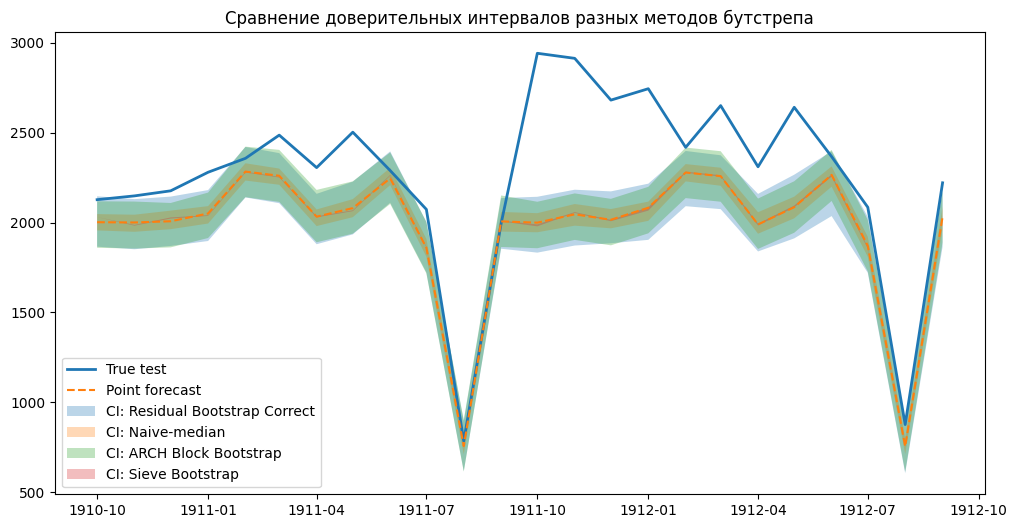

In [22]:
plt.figure(figsize=(12,6))
plt.plot(test.index[:forecast_steps], test_values, label='True test', linewidth=2)
plt.plot(test.index[:forecast_steps], forecast[:forecast_steps], label='Point forecast', linestyle='--')

to_plot = ['Residual Bootstrap Correct', 'Naive-median', 'ARCH Block Bootstrap', 'Sieve Bootstrap']

for name in results.keys():
    if name not in to_plot:
        continue

    lower = results[name]['lower']
    upper = results[name]['upper']

    plt.fill_between(test.index[:forecast_steps], lower, upper, alpha=0.3, label=f'CI: {name}')

plt.legend()
plt.title('Сравнение доверительных интервалов разных методов бутстрепа')
plt.show()